### **Import**

In [41]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt

### **Load data**

In [42]:
data = torch.load('../data/processed/pyg_data.pt')
print(data)
device = torch.device('cpu')
data = data.to(device)

Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


### **Define the model**

2-layer Graph Convolutional Network (GCN) structure:

In [43]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GCN(
    in_channels=data.x.shape[1],
    hidden_channels=64,
    out_channels=2,           
    dropout=0.5,
).to(device)

print(model)
print(f"Number of parameter: {sum(p.numel() for p in model.parameters()):,}")

GCN(
  (conv1): GCNConv(165, 64)
  (conv2): GCNConv(64, 2)
)
Number of parameter: 10,754


### **Define optimizer and loss**

In [44]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

n_licit   = (data.y[data.train_mask] == 0).sum().item()
n_illicit = (data.y[data.train_mask] == 1).sum().item()
weight = torch.tensor([1.0,  n_licit / n_illicit], dtype=torch.float).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=weight)

print(f"Class weights: licit={weight[0]:.2f}, illicit={weight[1]:.2f}")

Class weights: licit=1.00, illicit=8.19


### **Training loop**

In [45]:
from sklearn.metrics import f1_score

def train_one_epoch():
    model.train()                             
    optimizer.zero_grad()                        
    out = model(data.x, data.edge_index)             
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  
    loss.backward()                                 
    optimizer.step()                                
    return loss.item()

@torch.no_grad() 
def evaluate(mask):
    out = model(data.x, data.edge_index)
    pred = out[mask].argmax(dim=1) 
        
    correct = (pred == data.y[mask]).sum().item()
    total = mask.sum().item()
    accuracy = correct / total

    tp = ((pred == 1) & (data.y[mask] == 1)).sum().item()
    fn = ((pred == 0) & (data.y[mask] == 1)).sum().item()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        
    y_true_np = data.y[mask].cpu().numpy()
    y_pred_np = pred.cpu().numpy()
    f1_macro = f1_score(y_true_np, y_pred_np, average='macro')
    
    loss = criterion(out[mask], data.y[mask]).item()

    return accuracy, recall, f1_macro, loss

### **Train loop**

In [46]:
NUM_EPOCHS = 200
PATIENCE = 20  

history = {'train_loss': [], 'val_loss': [], 'val_recall': []}
best_val_recall = 0.0
epochs_no_improve = 0
best_epoch = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch()
    val_accuracy, val_recall, val_f1_macro, val_loss = evaluate(data.val_mask)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_recall'].append(val_recall)

    if val_recall > best_val_recall:
        best_val_recall = val_recall
        best_epoch = epoch
        torch.save(model.state_dict(), '../saved_models/gcn_best.pt')
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(f"Epoch {epoch:03d}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_recall={val_recall:.4f}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (best epoch: {best_epoch})")
        break

print(f"\nBest val recall: {best_val_recall:.4f} at epoch {best_epoch}")

Epoch 001: train_loss=0.8454, val_loss=0.7187, val_recall=0.6717
Epoch 002: train_loss=0.5505, val_loss=0.6105, val_recall=0.8545
Epoch 003: train_loss=0.4655, val_loss=0.6185, val_recall=0.9255
Epoch 004: train_loss=0.4287, val_loss=0.5863, val_recall=0.9492
Epoch 005: train_loss=0.4200, val_loss=0.6624, val_recall=0.9408
Epoch 006: train_loss=0.4004, val_loss=0.6588, val_recall=0.9543
Epoch 007: train_loss=0.3826, val_loss=0.6636, val_recall=0.9628
Epoch 008: train_loss=0.3730, val_loss=0.6881, val_recall=0.9695
Epoch 009: train_loss=0.3574, val_loss=0.6783, val_recall=0.9695
Epoch 010: train_loss=0.3524, val_loss=0.6649, val_recall=0.9712
Epoch 011: train_loss=0.3427, val_loss=0.6342, val_recall=0.9695
Epoch 012: train_loss=0.3372, val_loss=0.6233, val_recall=0.9746
Epoch 013: train_loss=0.3369, val_loss=0.5733, val_recall=0.9695
Epoch 014: train_loss=0.3295, val_loss=0.6355, val_recall=0.9695
Epoch 015: train_loss=0.3179, val_loss=0.5962, val_recall=0.9662
Epoch 016: train_loss=0.3

### **Training curves**

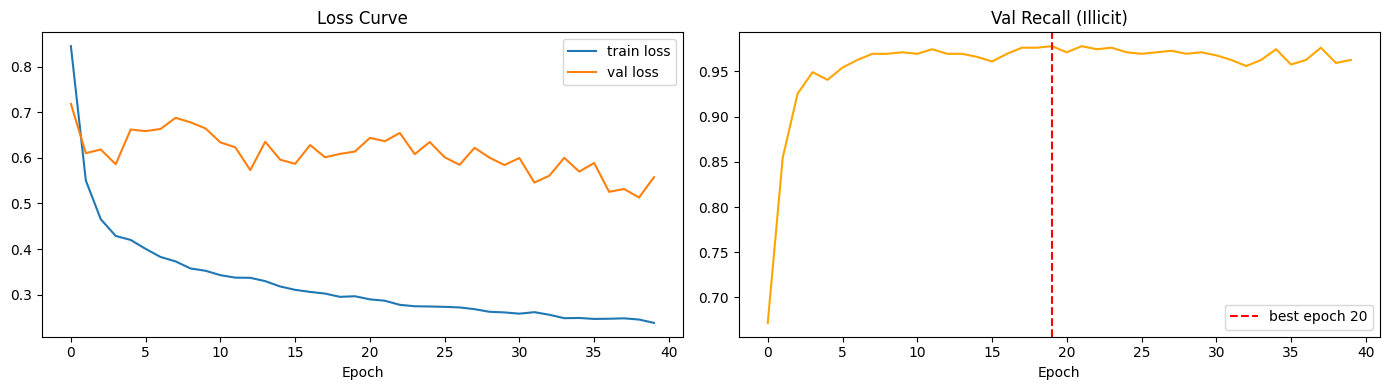

In [47]:
import os 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history['train_loss'], label='train loss')
ax1.plot(history['val_loss'], label='val loss')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history['val_recall'], color='orange')
ax2.axvline(x=best_epoch-1, color='red', linestyle='--', label=f'best epoch {best_epoch}')
ax2.set_title('Val Recall (Illicit)')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
save_dir = '../reports/figures'
file_path = f'{save_dir}/gcn_training_curve.png'
os.makedirs(save_dir, exist_ok=True)

plt.savefig(file_path, dpi=150)
plt.show()

### **Evaluation on test set**

In [48]:
model.load_state_dict(torch.load('../saved_models/gcn_best.pt'))

test_accuracy, test_recall, test_f1_macro, test_loss = evaluate(data.test_mask) 

print(f"Test Accuracy:         {test_accuracy:.4f}")
print(f"Test Recall (Illicit): {test_recall:.4f}")
print(f"Test F1-macro:         {test_f1_macro:.4f}")
print(f"Test Loss:             {test_loss:.4f}")

Test Accuracy:         0.4783
Test Recall (Illicit): 0.9178
Test F1-macro:         0.4011
Test Loss:             1.1330


### **Confusion Matrix**

In [49]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    pred = out[data.test_mask].argmax(dim=1).cpu()
    true = data.y[data.test_mask].cpu()

print(confusion_matrix(true, pred))
print(classification_report(true, pred, target_names=['licit', 'illicit']))

from sklearn.metrics import f1_score
f1 = f1_score(true, pred, average='macro')
print(f"F1-macro: {f1:.4f}")

[[6876 8711]
 [  65 1018]]
              precision    recall  f1-score   support

       licit       0.99      0.44      0.61     15587
     illicit       0.10      0.94      0.19      1083

    accuracy                           0.47     16670
   macro avg       0.55      0.69      0.40     16670
weighted avg       0.93      0.47      0.58     16670

F1-macro: 0.3994
